# **End-to-End QSAR Modeling for EGFR Inhibitors: From ChEMBL Bioactivity Data to Machine Learning Prediction and Biological Interpretation using SHAP**

## **Package Installation & Basic Imports**

In [1]:
!pip install chembl-webresource-client pandas rdkit matplotlib -q

from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00


## **Bioactivity Data Download from ChEMBL**

In [2]:
activity = new_client.activity
res = activity.filter(
    target_chembl_id='CHEMBL203',
    standard_type__in=['IC50', 'Ki'],
    standard_units='nM'
)

df = pd.DataFrame.from_records(res)
print("Total rows downloaded:", len(df))
df.to_csv('EGFR_raw.csv', index=False)
print("Raw file saved!")

Total rows downloaded: 25604
Raw file saved!


## **Data Curation**




In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem

df = pd.read_csv('EGFR_raw.csv', low_memory=False)

cols = ['molecule_chembl_id', 'canonical_smiles', 'standard_type',
        'standard_relation', 'standard_value', 'standard_units']

df = df[cols].copy()

df = df[df['standard_type'].isin(['IC50', 'Ki'])]
df = df[df['standard_units'] == 'nM']
df = df[df['standard_relation'] == '=']

df['pIC50'] = -np.log10(df['standard_value'] * 1e-9)

def clean_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=False)

df['clean_smiles'] = df['canonical_smiles'].apply(clean_smiles)
df = df.dropna(subset=['clean_smiles'])

df = df.drop_duplicates(subset=['clean_smiles'], keep='first')

print("Final rows:", len(df))
print(df['pIC50'].describe())

df.to_csv('EGFR_curated.csv', index=False)
print("Saved as EGFR_curated.csv")

[05:52:43] SMILES Parse Error: syntax error while parsing: nan
[05:52:43] SMILES Parse Error: check for mistakes around position 2:
[05:52:43] nan
[05:52:43] ~^
[05:52:43] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[05:52:43] SMILES Parse Error: syntax error while parsing: nan
[05:52:43] SMILES Parse Error: check for mistakes around position 2:
[05:52:43] nan
[05:52:43] ~^
[05:52:43] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[05:52:43] SMILES Parse Error: syntax error while parsing: nan
[05:52:43] SMILES Parse Error: check for mistakes around position 2:
[05:52:43] nan
[05:52:43] ~^
[05:52:43] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[05:52:43] SMILES Parse Error: syntax error while parsing: nan
[05:52:43] SMILES Parse Error: check for mistakes around position 2:
[05:52:43] nan
[05:52:43] ~^
[05:52:43] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[05:52:43] SMILES Parse Error: syntax error while pa

Final rows: 10592
count    10590.000000
mean         6.915765
std          1.397870
min          1.259637
25%          5.911246
50%          7.000000
75%          8.000000
max         17.299989
Name: pIC50, dtype: float64
Saved as EGFR_curated.csv


## **Molecular Descriptor & Fingerprint Generation**

10592
(10592, 217)
(10592, 2048)


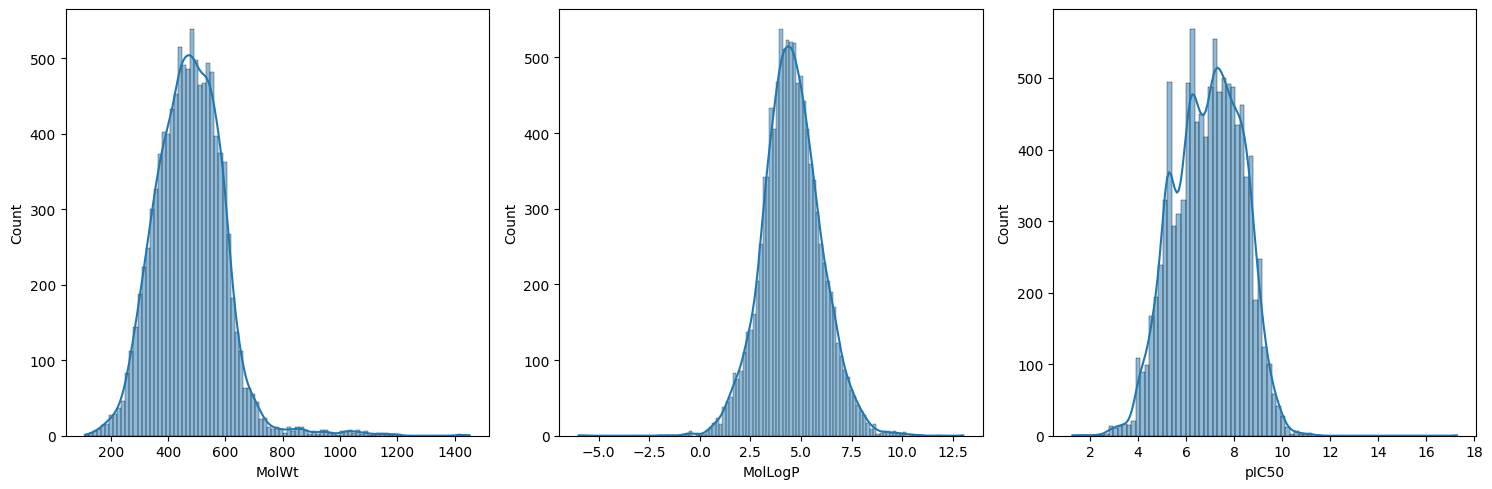

pIC50          1.000000
EState_VSA8    0.342681
fr_NH1         0.313652
SMR_VSA3       0.303875
SlogP_VSA10    0.283355
SlogP_VSA1     0.269304
fr_aniline     0.267095
Chi2n          0.264135
Chi2v          0.259769
PEOE_VSA9      0.259501
Name: pIC50, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors

RDLogger.DisableLog('rdApp.*')

df = pd.read_csv('EGFR_curated.csv')
df['mol'] = df['clean_smiles'].apply(Chem.MolFromSmiles)

descriptor_names = [x[0] for x in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

def calc_desc(mol):
    if mol is None:
        return [np.nan] * len(descriptor_names)
    return calc.CalcDescriptors(mol)

desc_df = pd.DataFrame(df['mol'].apply(calc_desc).tolist(), columns=descriptor_names)

morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def get_fp(mol):
    if mol is None:
        return np.zeros(2048, dtype=int)
    return np.array(morgan_gen.GetFingerprint(mol))

fp_array = np.vstack(df['mol'].apply(get_fp))

final_df = pd.concat([df[['clean_smiles', 'pIC50']].reset_index(drop=True), desc_df], axis=1)
final_df = final_df.dropna(axis=1, how='all')

final_df.to_csv('EGFR_descriptors.csv', index=False)
np.save('EGFR_morgan_fp.npy', fp_array)

print(len(final_df))
print(desc_df.shape)
print(fp_array.shape)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(final_df['MolWt'], kde=True)

plt.subplot(1, 3, 2)
sns.histplot(final_df['MolLogP'], kde=True)

plt.subplot(1, 3, 3)
sns.histplot(final_df['pIC50'], kde=True)

plt.tight_layout()
plt.savefig('descriptor_distributions.png')
plt.show()

numeric_df = final_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['pIC50'].sort_values(ascending=False)
print(corr.head(10))

final_df.to_csv('EGFR_full_features.csv', index=False)

## **Imports**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem

## **SCHEMA CHECK + CLEAN TARGET**

In [6]:
df = pd.read_csv('EGFR_full_features.csv')
df = df.dropna(subset=['pIC50'])
df = df.replace([np.inf, -np.inf], np.nan).dropna()

## **Feature Preparation & Scaffold Split**

In [9]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold is None:
        return None
    return Chem.MolToSmiles(scaffold, isomericSmiles=False)

df['scaffold'] = df['clean_smiles'].apply(get_scaffold)
df = df.dropna(subset=['scaffold'])

scaffolds = df['scaffold'].unique()
np.random.seed(42)
np.random.shuffle(scaffolds)

train_scaffolds = scaffolds[:int(0.8 * len(scaffolds))]
train_df = df[df['scaffold'].isin(train_scaffolds)].copy()
test_df = df[~df['scaffold'].isin(train_scaffolds)].copy()

print(f"Train compounds: {len(train_df)}")
print(f"Test compounds: {len(test_df)}")

Train compounds: 8462
Test compounds: 2115


## **Hybrid Feature Generation: Morgan Fingerprints + Descriptors**

In [22]:
from rdkit.Chem import AllChem

def get_morgan_fp(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits))

print("Generating Morgan Fingerprints...")
fp_array = np.array([get_morgan_fp(s) for s in train_df['clean_smiles']])
fp_df = pd.DataFrame(fp_array, columns=[f'FP_{i}' for i in range(1024)], index=train_df.index)

X_train_hybrid = pd.concat([X_train.reset_index(drop=True), fp_df.reset_index(drop=True)], axis=1)

fp_test = np.array([get_morgan_fp(s) for s in test_df['clean_smiles']])
fp_test_df = pd.DataFrame(fp_test, columns=[f'FP_{i}' for i in range(1024)], index=test_df.index)
X_test_hybrid = pd.concat([X_test.reset_index(drop=True), fp_test_df.reset_index(drop=True)], axis=1)

print("Hybrid feature shape:", X_train_hybrid.shape)

Hybrid feature shape: (8462, 1232)


## **Feature Selection & Scaling**

In [23]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(RandomForestRegressor(n_estimators=200, random_state=42), threshold="median")
selector.fit(X_train_hybrid, y_train)

X_train_sel = selector.transform(X_train_hybrid)
X_test_sel = selector.transform(X_test_hybrid)

print("Selected features:", X_train_sel.shape[1])

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_sel)
X_test_final = scaler.transform(X_test_sel)


Selected features: 616


## **PCA**

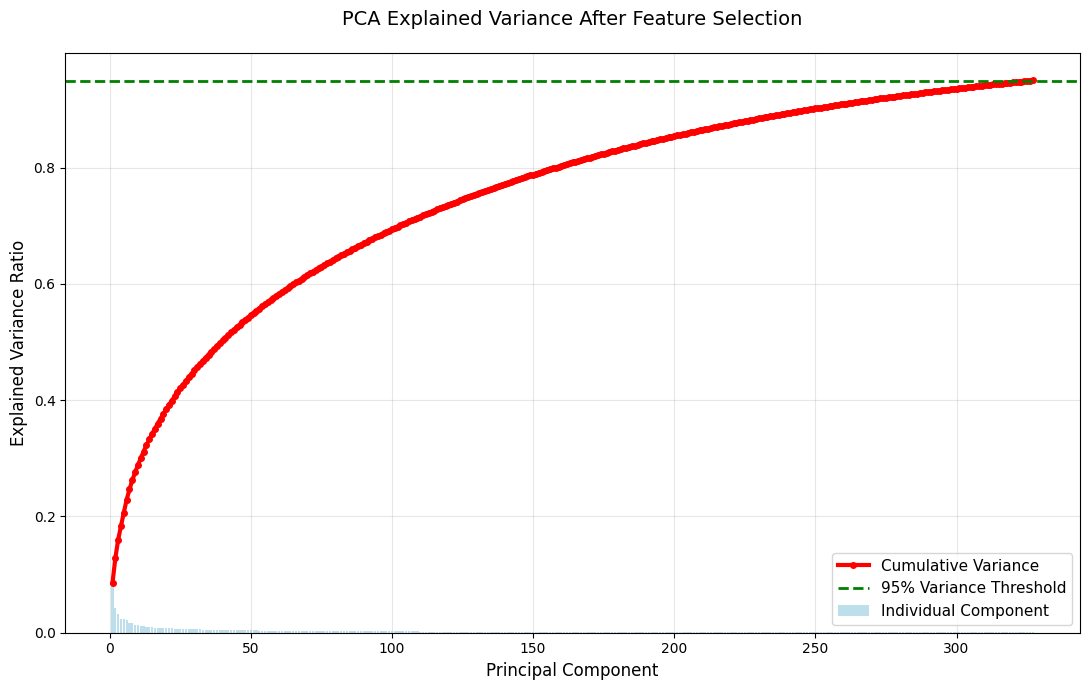

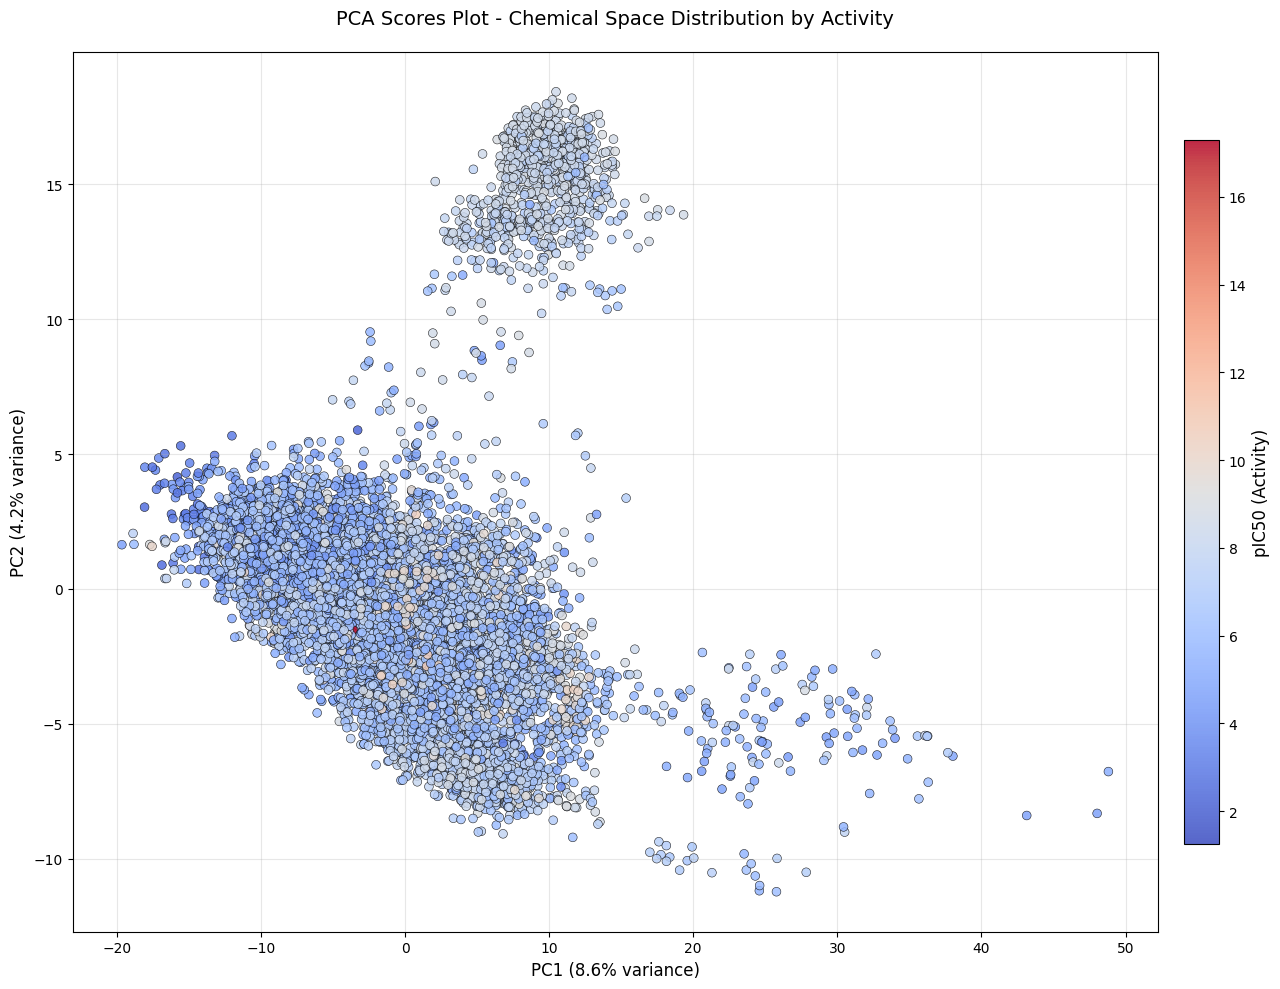

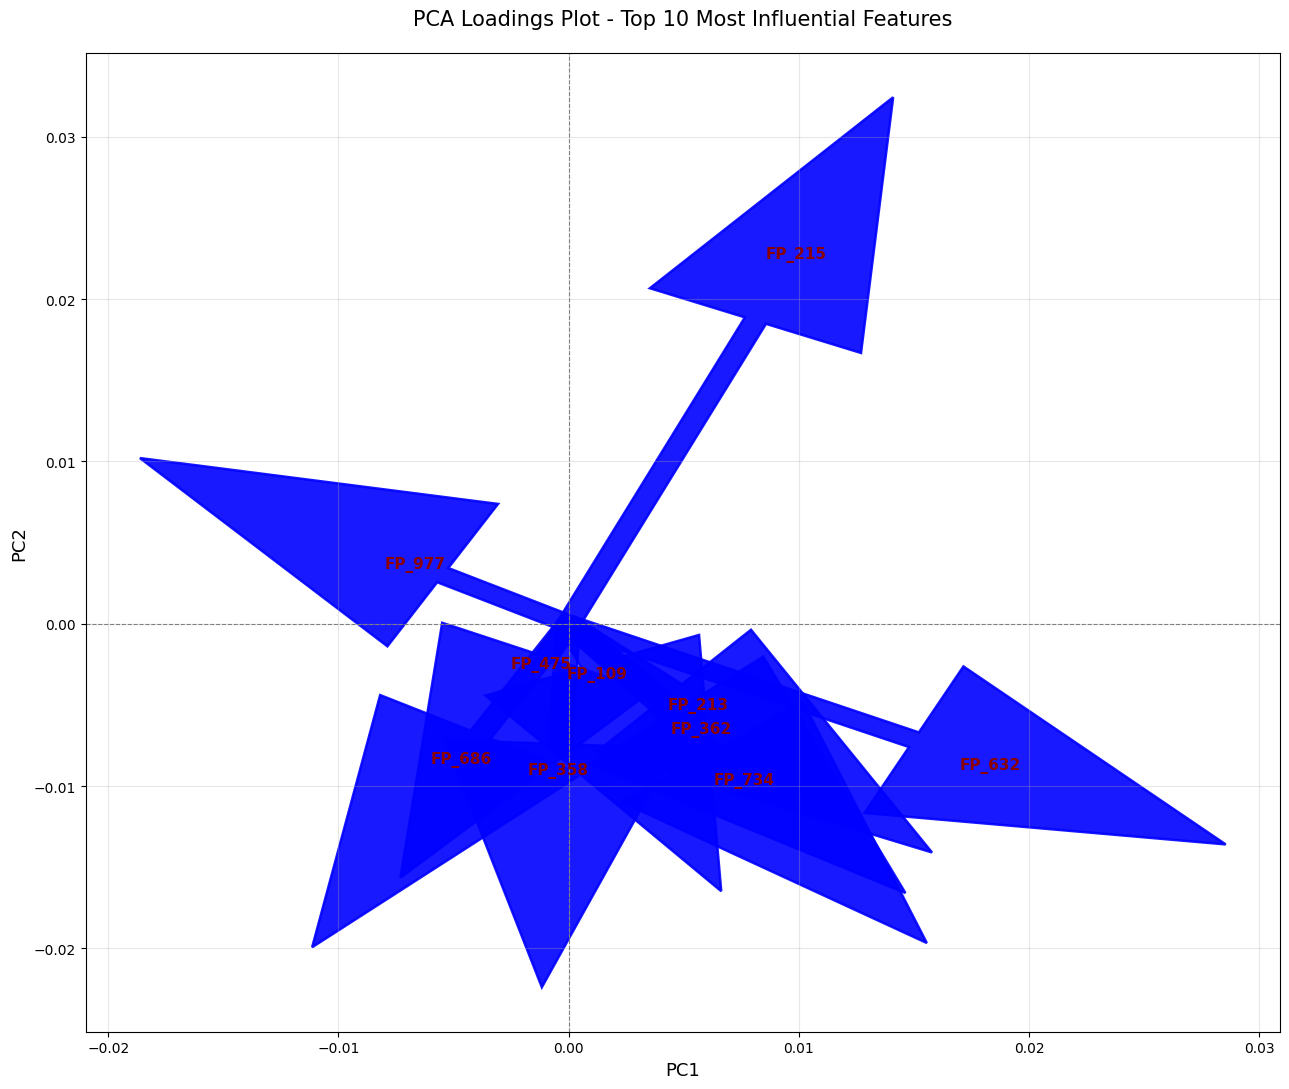

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(11, 7))
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.8, color='lightblue',
        label='Individual Component', width=0.8)
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, 'r-', linewidth=3,
         label='Cumulative Variance', marker='o', markersize=4)

plt.axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% Variance Threshold')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('PCA Explained Variance After Feature Selection', fontsize=14, pad=20)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_explained_variance_f.png', dpi=400, bbox_inches='tight')
plt.show()
plt.figure(figsize=(14, 10))
scatter = plt.scatter(X_full_pca[:, 0], X_full_pca[:, 1],
                     c=y_full, cmap='coolwarm', alpha=0.85, s=40,
                     edgecolors='black', linewidth=0.4)

cbar = plt.colorbar(scatter, label='pIC50 (Activity)', shrink=0.8, pad=0.02)
cbar.set_label('pIC50 (Activity)', fontsize=12)

plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)', fontsize=12)
plt.title('PCA Scores Plot - Chemical Space Distribution by Activity', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_scores_f.png', dpi=400, bbox_inches='tight')
plt.show()
plt.figure(figsize=(13, 11))

loadings = pd.DataFrame(pca.components_.T,
                       columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                       index=X_train_hybrid.columns[selector.get_support()])

top_features = loadings.abs().sum(axis=1).nlargest(10).index

for feature in top_features:
    x = loadings.loc[feature, 'PC1']
    y = loadings.loc[feature, 'PC2']
    plt.arrow(0, 0, x, y, head_width=0.01, head_length=0.015,
             fc='blue', ec='blue', alpha=0.9, linewidth=1.8)
    plt.text(x*1.22, y*1.22, feature, fontsize=11, color='darkred',
            ha='center', va='center', weight='bold')

plt.xlabel('PC1', fontsize=13)
plt.ylabel('PC2', fontsize=13)
plt.title('PCA Loadings Plot - Top 10 Most Influential Features', fontsize=15, pad=20)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='gray', lw=0.8, linestyle='--')
plt.axvline(0, color='gray', lw=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('pca_loadings_f.png', dpi=500, bbox_inches='tight')
plt.show()

## **Model Training, Evaluation & Ensemble**

In [28]:
from sklearn.ensemble import VotingRegressor

models = {
    "XGBoost_Tuned": XGBRegressor(n_estimators=800, max_depth=10, learning_rate=0.03,
                                 subsample=0.85, colsample_bytree=0.8,
                                 random_state=42, n_jobs=-1),
    "RandomForest": RandomForestRegressor(n_estimators=600, max_depth=14,
                                         min_samples_leaf=1, random_state=42, n_jobs=-1)
}

predictions = {}
metrics = {}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    pred = model.predict(X_test_final)
    predictions[name] = pred
    metrics[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "Pearson": stats.pearsonr(y_test, pred)[0]
    }
ensemble = VotingRegressor([('xgb', models['XGBoost_Tuned']), ('rf', models['RandomForest'])])
ensemble.fit(X_train_final, y_train)
ens_pred = ensemble.predict(X_test_final)

metrics["Ensemble"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, ens_pred)),
    "MAE": mean_absolute_error(y_test, ens_pred),
    "R2": r2_score(y_test, ens_pred),
    "Pearson": stats.pearsonr(y_test, ens_pred)[0]
}

print("\n MODEL PERFORMANCE ")
print(pd.DataFrame(metrics).T.round(4))


 MODEL PERFORMANCE 
                 RMSE     MAE      R2  Pearson
XGBoost_Tuned  0.8749  0.6590  0.5995   0.7762
RandomForest   0.9376  0.7115  0.5401   0.7410
Ensemble       0.8967  0.6785  0.5794   0.7660


## **SHAP Explainability & Biological Interpretation**

/tmp/ipykernel_692/443002874.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_final,


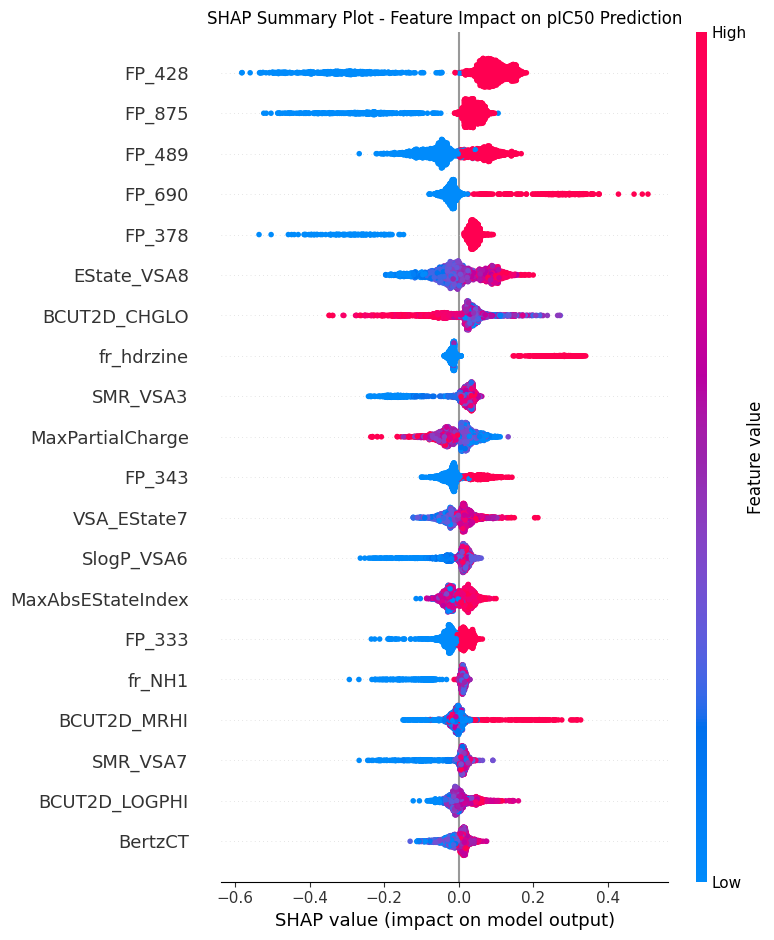

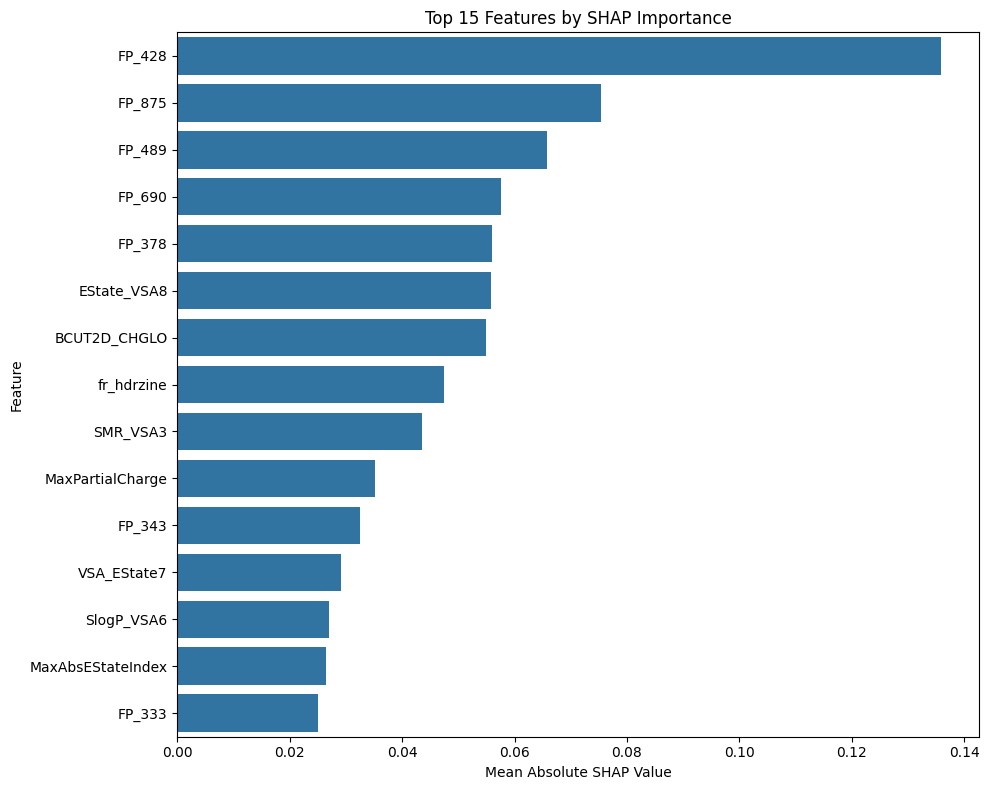


=== TOP 10 MOST IMPORTANT FEATURES (SHAP) ===
              Feature  Mean_SHAP
360            FP_428   0.135863
551            FP_875   0.075425
387            FP_489   0.065775
474            FP_690   0.057499
335            FP_378   0.056021
89        EState_VSA8   0.055860
20       BCUT2D_CHGLO   0.054971
150        fr_hdrzine   0.047437
63           SMR_VSA3   0.043483
10   MaxPartialCharge   0.035158


In [29]:
import shap
best_model = models["XGBoost_Tuned"]
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_final)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_final,
                 feature_names=X_train_hybrid.columns[selector.get_support()],
                 max_display=20, show=False)
plt.title("SHAP Summary Plot - Feature Impact on pIC50 Prediction")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=400, bbox_inches='tight')
plt.show()
shap_importance = np.abs(shap_values).mean(0)
feature_names = X_train_hybrid.columns[selector.get_support()]

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': shap_importance
}).sort_values('Mean_SHAP', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=shap_df['Mean_SHAP'].head(15), y=shap_df['Feature'].head(15))
plt.title('Top 15 Features by SHAP Importance')
plt.xlabel('Mean Absolute SHAP Value')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=400)
plt.show()

print("\n=== TOP 10 MOST IMPORTANT FEATURES (SHAP) ===")
print(shap_df.head(10))

## **Model Evaluation**

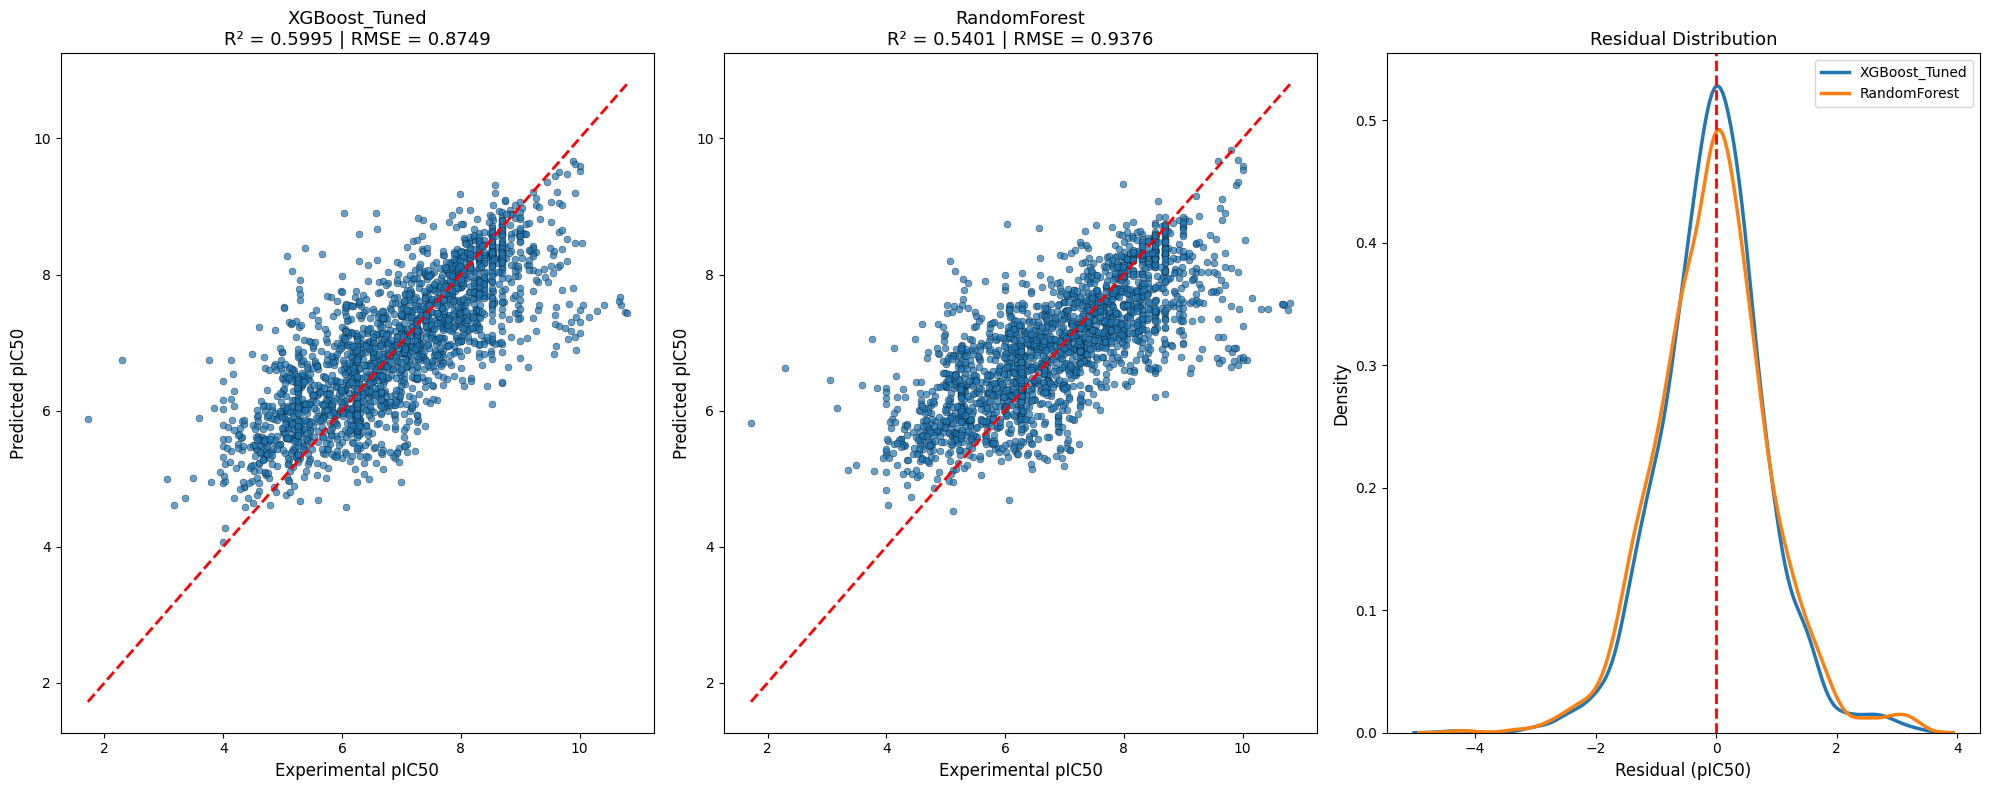

In [31]:
fig = plt.figure(figsize=(20, 8))
for i, (name, pred) in enumerate(predictions.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, pred, alpha=0.7, s=25, edgecolors='k', linewidth=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Experimental pIC50', fontsize=12)
    plt.ylabel('Predicted pIC50', fontsize=12)
    plt.title(f'{name}\nR² = {metrics[name]["R2"]:.4f} | RMSE = {metrics[name]["RMSE"]:.4f}', fontsize=13)
plt.subplot(1, 3, 3)
for name, pred in predictions.items():
    residuals = y_test - pred
    sns.kdeplot(residuals, label=name, linewidth=2.5)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Residual (pIC50)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Residual Distribution', fontsize=13)
plt.legend()

plt.tight_layout()
plt.savefig('FINAL_QSAR_EVALUATION.png', dpi=400, bbox_inches='tight')
plt.show()

# **Chemical Space Visualization using t-SNE**

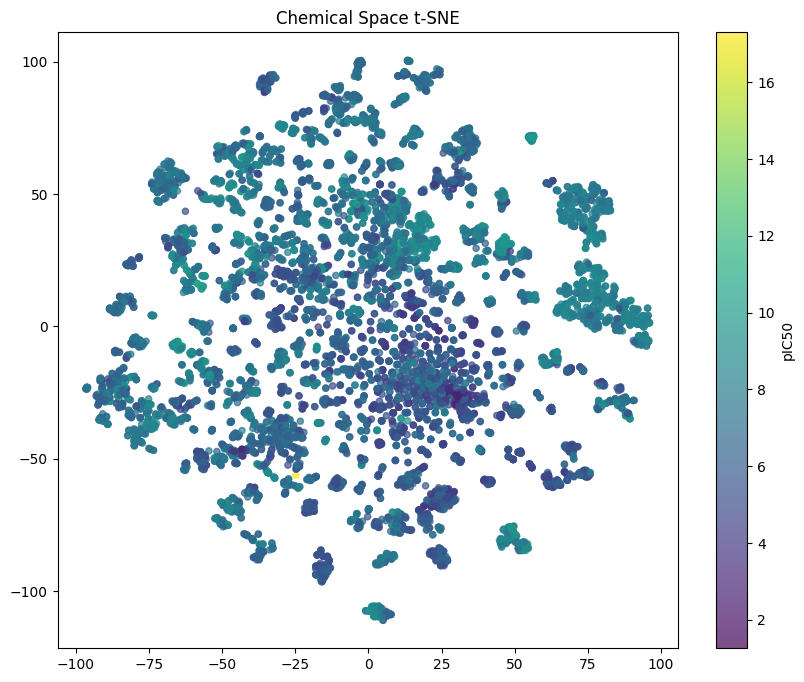

In [32]:
def get_morgan_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits))

fps = np.array([get_morgan_fp(s) for s in df['clean_smiles']])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_coords = tsne.fit_transform(fps)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=df['pIC50'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(label='pIC50')
plt.title('Chemical Space t-SNE')
plt.savefig('chemical_space.png', dpi=300)
plt.show()

In [33]:
corr = pd.concat([X_train, y_train], axis=1).corr()['pIC50'].sort_values(ascending=False)
print(corr.head(15))

pIC50             1.000000
EState_VSA8       0.348829
fr_NH1            0.297945
SMR_VSA3          0.286890
SlogP_VSA10       0.284482
fr_aniline        0.271490
HeavyAtomMolWt    0.266771
MolWt             0.265777
ExactMolWt        0.265461
Chi2v             0.265450
MolMR             0.262186
BertzCT           0.259531
Chi2n             0.258758
Chi0v             0.257776
SlogP_VSA1        0.257322
Name: pIC50, dtype: float64
